# Credit Risk & Customer Financial Health Analytics

## Technical Appendix (Jupyter Notebook)

**Module:** ITS 2122 – Python for Data Science & AI

**Project:** Credit Risk & Customer Financial Health Analytics for a Digital Lending Provider

**Semester:** Semester 3 – 2026

**Group Name:**  BUG HUNTERS

### Group Members

| Student ID | Name |
|------------|------|
|S001 | H.K.Rashmi Malshani|
|S002 | L.G.Dhanuka Lakshan|
|S003 | M.S.P.B. muhandiram|
|S004 | C.K. Punchihewa|
|S004 | P.M.Yashmika|

---

### Notebook Purpose

This notebook presents the complete technical implementation of the Credit Risk & Customer Financial Health Analytics project. It follows the project specification provided for ITS 2122 and documents every stage of the data analysis lifecycle, including:

- Data Loading and Preprocessing
- Data Cleaning and Validation
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Credit Risk Segmentation
- Business Insights and Strategic Recommendations
- External API Integration

All analyses have been implemented using Python, Pandas, NumPy, Matplotlib, Seaborn, and Requests while following a reproducible, well-documented workflow.

# Library Ingestion & Setup
## Step 1 – Import Required Libraries

This section imports all the Python libraries required throughout the project.

The libraries are used for:

- Pandas – Data loading and manipulation
- NumPy – Numerical computations
- Matplotlib – Data visualization
- Seaborn – Statistical visualization
- Requests – External API integration
- Warnings – Suppress unnecessary warning messages

Additionally, a consistent visualization style is configured to ensure that all charts are professional and easy to interpret.

In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings

# Suppress unnecessary warnings for cleaner notebook output
warnings.filterwarnings("ignore")

# Configure visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("All required libraries loaded successfully.")

✅ All required libraries loaded successfully.


## Phase 1: Data Sanitation and Preprocessing

The objective of this phase is to transform the raw credit-card dataset into a clean, reliable, and analysis-ready format. High-quality data is essential for producing accurate insights and meaningful business recommendations.

### Step 1: Load the Dataset

In this step, the notebook:

- Imports the customer credit-card dataset from the **data/raw** directory.
- Automatically detects whether the dataset is in **CSV** or **Excel (.xls/.xlsx)** format.
- Loads the dataset into a **Pandas DataFrame**.
- Verifies that the dataset has been loaded successfully.
- Displays the dataset dimensions (rows and columns).
- Shows the first few records for an initial inspection.
- Implements error handling to gracefully manage missing files or loading issues.

This approach ensures the notebook remains reproducible and can be executed successfully even if the dataset format changes between CSV and Excel.

In [ ]:
# Phase 1 - Step 1 : Load Dataset

import os

# Define the raw data directory
raw_dir = "../data/raw"

print("=" * 50)
print("STEP 1 : DATA LOADING")
print("=" * 50)

try:
    # Verify whether the raw data directory exists
    if not os.path.exists(raw_dir):
        raise FileNotFoundError(
            f"Raw data directory not found: {raw_dir}"
        )

    print(f"Raw data directory found: {raw_dir}")

    # Search for supported dataset files
    supported_extensions = (".csv", ".xls", ".xlsx")

    files = [
        file for file in os.listdir(raw_dir)
        if file.lower().startswith("default of credit card")
        and file.lower().endswith(supported_extensions)
    ]

    if len(files) == 0:
        raise FileNotFoundError(
            "No supported dataset found in the data/raw directory."
        )

    # Select the first matching dataset
    file_name = files[0]
    data_path = os.path.join(raw_dir, file_name)

    print(f"Dataset found: {file_name}")

    # Load dataset according to file type
    if file_name.lower().endswith(".csv"):
        df_raw = pd.read_csv(data_path, skiprows=1)

    elif file_name.lower().endswith((".xls", ".xlsx")):
        df_raw = pd.read_excel(data_path, skiprows=1)

    # Display loading summary
    print("\nDataset loaded successfully!")
    print(f"Rows    : {df_raw.shape[0]:,}")
    print(f"Columns : {df_raw.shape[1]}")

    print("\nColumn Names:")
    print(df_raw.columns.tolist())

    print("\nFirst Five Records:")
    display(df_raw.head())

    print("\nData Loading Completed Successfully.")

except FileNotFoundError as fnf_error:
    print("\nFile Not Found Error")
    print(fnf_error)

except PermissionError:
    print("\nPermission Error")
    print("Please close the dataset file if it is currently open.")

except pd.errors.EmptyDataError:
    print("\nThe dataset file is empty.")

except Exception as error:
    print("\nUnexpected Error")
    print(error)


STEP 1 : DATA LOADING
Raw data directory found: ../data/raw
Dataset found: default of credit card clients.xls

Dataset loaded successfully!
Rows    : 30,000
Columns : 25

Column Names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

First Five Records:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Data Loading Completed Successfully.


### Step 2: Initial Data Assessment

Before performing any cleaning or transformation, it is important to understand the structure and quality of the dataset. This assessment helps identify potential data quality issues that may affect later analysis.

In this step, the following checks are performed:

- Inspect the dataset structure, data types, and memory usage.
- Examine summary statistics for numerical variables.
- Identify missing (null) values in each column.
- Review the original column names.
- Analyze the categorical variables (`SEX`, `EDUCATION`, and `MARRIAGE`) to identify valid, invalid, and undocumented category codes.

These checks provide a clear understanding of the dataset and guide the subsequent data cleaning and preprocessing decisions.

In [17]:
# 2. Initial Assessment
print("--- Data Info ---")
print(df_raw.info())

print("\n--- Missing Values ---")
print(df_raw.isnull().sum())

print("\n--- Raw Columns in df_raw ---")
print(df_raw.columns.tolist())

# Check demographic column values to understand raw codes
demographics = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in demographics:
    if col in df_raw.columns:
        print(f"\nValue counts for {col}:")
        print(df_raw[col].value_counts(dropna=False))


--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14 

In [18]:
# 3. Rename Columns to python_friendly_names
rename_dict = {
    'LIMIT_BAL': 'limit_balance',
    'SEX': 'sex',
    'EDUCATION': 'education',
    'MARRIAGE': 'marriage',
    'AGE': 'age',
    'PAY_0': 'pay_status_1',  # In UCI, PAY_0 is the first month's repayment status
    'PAY_2': 'pay_status_2',
    'PAY_3': 'pay_status_3',
    'PAY_4': 'pay_status_4',
    'PAY_5': 'pay_status_5',
    'PAY_6': 'pay_status_6',
    'BILL_AMT1': 'bill_amount_1',
    'BILL_AMT2': 'bill_amount_2',
    'BILL_AMT3': 'bill_amount_3',
    'BILL_AMT4': 'bill_amount_4',
    'BILL_AMT5': 'bill_amount_5',
    'BILL_AMT6': 'bill_amount_6',
    'PAY_AMT1': 'pay_amount_1',
    'PAY_AMT2': 'pay_amount_2',
    'PAY_AMT3': 'pay_amount_3',
    'PAY_AMT4': 'pay_amount_4',
    'PAY_AMT5': 'pay_amount_5',
    'PAY_AMT6': 'pay_amount_6',
    'default payment next month': 'default_next_month'
}

# Handle minor name variations if any
if 'default payment next month' not in df_raw.columns and 'default.payment.next.month' in df_raw.columns:
    rename_dict['default.payment.next.month'] = 'default_next_month'

df_clean = df_raw.rename(columns=rename_dict)

# Drop ID column since it has no predictive power
if 'ID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['ID'])

print("Columns renamed successfully!")
print(df_clean.columns.tolist())


Columns renamed successfully!
['limit_balance', 'sex', 'education', 'marriage', 'age', 'pay_status_1', 'pay_status_2', 'pay_status_3', 'pay_status_4', 'pay_status_5', 'pay_status_6', 'bill_amount_1', 'bill_amount_2', 'bill_amount_3', 'bill_amount_4', 'bill_amount_5', 'bill_amount_6', 'pay_amount_1', 'pay_amount_2', 'pay_amount_3', 'pay_amount_4', 'pay_amount_5', 'pay_amount_6', 'default_next_month']


In [19]:
# 4. Decode Categories (Sex, Education, Marriage)
# Decode numeric codes to business-friendly readable labels

# SEX: 1 = Male, 2 = Female
sex_map = {1: 'Male', 2: 'Female'}

# EDUCATION: 1 = Graduate School, 2 = University, 3 = High School, 4,5,6,0 = Others/Unknown
edu_map = {
    1: 'Graduate School',
    2: 'University',
    3: 'High School',
    4: 'Others',
    5: 'Others',
    6: 'Others',
    0: 'Others'
}

# MARRIAGE: 1 = Married, 2 = Single, 3 = Others (0 is undocumented/unknown)
marriage_map = {
    1: 'Married',
    2: 'Single',
    3: 'Others',
    0: 'Others'
}

df_clean['sex'] = df_clean['sex'].map(sex_map)
df_clean['education'] = df_clean['education'].map(edu_map)
df_clean['marriage'] = df_clean['marriage'].map(marriage_map)

print("--- Decoded Category Distributions ---")
print("\nSex:\n", df_clean['sex'].value_counts())
print("\nEducation:\n", df_clean['education'].value_counts())
print("\nMarriage:\n", df_clean['marriage'].value_counts())


--- Decoded Category Distributions ---

Sex:
 sex
Female    18112
Male      11888
Name: count, dtype: int64

Education:
 education
University         14030
Graduate School    10585
High School         4917
Others               468
Name: count, dtype: int64

Marriage:
 marriage
Single     15964
Married    13659
Others       377
Name: count, dtype: int64


In [20]:
# 5. Handle Duplicates & Invalid Values
# Find duplicate rows
dups = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {dups}")
if dups > 0:
    df_clean = df_clean.drop_duplicates()
    print("Duplicate rows removed.")

# Age range validation
print(f"Age range: {df_clean['age'].min()} to {df_clean['age'].max()} years")

# Check limit balance range
print(f"Limit Balance range: {df_clean['limit_balance'].min()} to {df_clean['limit_balance'].max()} TWD")

# Verify repayment status ranges
pay_cols = [f'pay_status_{i}' for i in range(1, 7)]
print("\nRepayment status ranges (should be between -2 and 9):")
for col in pay_cols:
    print(f"{col}: min={df_clean[col].min()}, max={df_clean[col].max()}")


Number of duplicate rows: 35
Duplicate rows removed.
Age range: 21 to 79 years
Limit Balance range: 10000 to 1000000 TWD

Repayment status ranges (should be between -2 and 9):
pay_status_1: min=-2, max=8
pay_status_2: min=-2, max=8
pay_status_3: min=-2, max=8
pay_status_4: min=-2, max=8
pay_status_5: min=-2, max=8
pay_status_6: min=-2, max=8


In [21]:
# 6. Feature Engineering
bill_cols = [f'bill_amount_{i}' for i in range(1, 7)]
pay_amt_cols = [f'pay_amount_{i}' for i in range(1, 7)]
pay_status_cols = [f'pay_status_{i}' for i in range(1, 7)]

# A. Average bill amount
df_clean['average_bill'] = df_clean[bill_cols].mean(axis=1)

# B. Average payment amount
df_clean['average_payment'] = df_clean[pay_amt_cols].mean(axis=1)

# C. Payment-to-bill ratio (overall sum of payments / sum of bills to avoid divide-by-zero on individual months)
total_bills = df_clean[bill_cols].sum(axis=1)
total_payments = df_clean[pay_amt_cols].sum(axis=1)
df_clean['payment_to_bill_ratio'] = np.where(total_bills > 0, total_payments / total_bills, 0.0)

# D. Number of delayed months (pay_status > 0 indicates delay)
df_clean['delayed_months'] = (df_clean[pay_status_cols] > 0).sum(axis=1)

# E. Maximum delay in repayment status
df_clean['max_delay'] = df_clean[pay_status_cols].max(axis=1)

# F. Balance trend (recent bill - oldest bill)
df_clean['balance_trend'] = df_clean['bill_amount_1'] - df_clean['bill_amount_6']

# G. Credit utilization (recent bill amount / limit balance)
df_clean['credit_utilization'] = df_clean['bill_amount_1'] / df_clean['limit_balance']

print("Behavioral features engineered successfully. Preview:")
preview_cols = ['limit_balance', 'average_bill', 'average_payment', 'payment_to_bill_ratio', 'delayed_months', 'max_delay', 'credit_utilization']
print(df_clean[preview_cols].head())


Behavioral features engineered successfully. Preview:
   limit_balance  average_bill  average_payment  payment_to_bill_ratio  \
0          20000   1284.000000       114.833333               0.089434   
1         120000   2846.166667       833.333333               0.292791   
2          90000  16942.166667      1836.333333               0.108388   
3          50000  38555.666667      1398.000000               0.036259   
4          50000  18223.166667      9841.500000               0.540054   

   delayed_months  max_delay  credit_utilization  
0               2          2            0.195650  
1               2          2            0.022350  
2               0          0            0.324878  
3               0          0            0.939800  
4               0          0            0.172340  


In [22]:
# 7. Persist Cleaned Data
import os
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "cleaned_credit_data.csv")

df_clean.to_csv(output_path, index=False)
print(f"Cleaned dataset saved successfully to: {output_path}")
print(f"Cleaned dataset shape: {df_clean.shape}")


Cleaned dataset saved successfully to: ../data/processed\cleaned_credit_data.csv
Cleaned dataset shape: (29965, 31)


## Phase 2: Exploratory Data Analysis & Insight Generation
In this phase, we analyze the distribution of credit defaults and construct the mandatory 8+ visualizations with appropriate business interpretations.

### Required Analyses:
- **Default-Rate Analysis** (Age bands, education levels, marital status, credit-limit tiers).
- **Repayment-Behaviour Analysis** (Delinquency months and relationship to default).
- **Financial Position Analysis** (Comparison of bills, payments, and payment-to-bill ratios between defaulters and non-defaulters).
- **Relationship Analysis** (Correlation heatmap between metrics).

--- Default Counts ---
default_next_month
0    23335
1     6630
Name: count, dtype: int64

--- Default Rates (%) ---
default_next_month
0    77.874187
1    22.125813
Name: proportion, dtype: float64


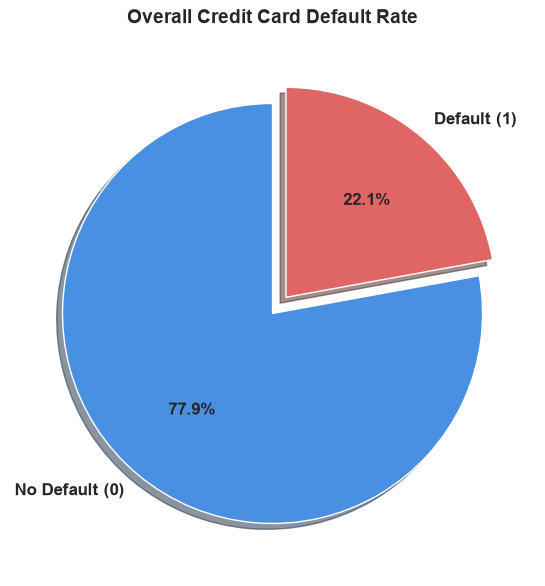

In [23]:
# Analysis & Plot 1: Overall default rate distribution
import matplotlib.pyplot as plt
import seaborn as sns

default_counts = df_clean['default_next_month'].value_counts()
default_rates = df_clean['default_next_month'].value_counts(normalize=True) * 100

print("--- Default Counts ---")
print(default_counts)
print("\n--- Default Rates (%) ---")
print(default_rates)

# Sleek Pie Chart
fig, ax = plt.subplots(figsize=(6, 6))
colors = ['#4A90E2', '#E06666']  # Sleek blue and red
ax.pie(default_counts, labels=['No Default (0)', 'Default (1)'], autopct='%1.1f%%', 
       startangle=90, colors=colors, explode=(0, 0.1), shadow=True,
       textprops={'fontsize': 12, 'weight': 'bold'})
ax.set_title('Overall Credit Card Default Rate', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()


   age_band  default_next_month  default_rate
0  Under 25            0.271711     27.171077
1     25-34            0.203295     20.329459
2     35-44            0.218250     21.825044
3     45-54            0.239480     23.947991
4       55+            0.266857     26.685660


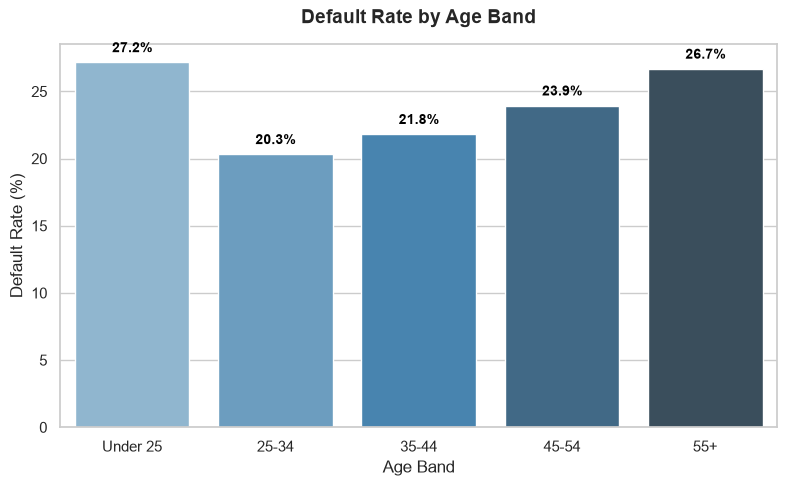

In [24]:
# Analysis & Plot 2: Default rate by Age Bands
# Group ages into standard bands: Under 25, 25-34, 35-44, 45-54, 55+
age_bins = [0, 24, 34, 44, 54, 100]
age_labels = ['Under 25', '25-34', '35-44', '45-54', '55+']
df_clean['age_band'] = pd.cut(df_clean['age'], bins=age_bins, labels=age_labels)

age_default = df_clean.groupby('age_band')['default_next_month'].mean().reset_index()
age_default['default_rate'] = age_default['default_next_month'] * 100

print(age_default)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=age_default, x='age_band', y='default_rate', palette='Blues_d', ax=ax)
ax.set_title('Default Rate by Age Band', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Age Band', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='center', fontsize=10, weight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()


         education  default_next_month  default_rate
1      High School            0.251679     25.167854
3       University            0.237392     23.739211
0  Graduate School            0.192370     19.236959
2           Others            0.070513      7.051282


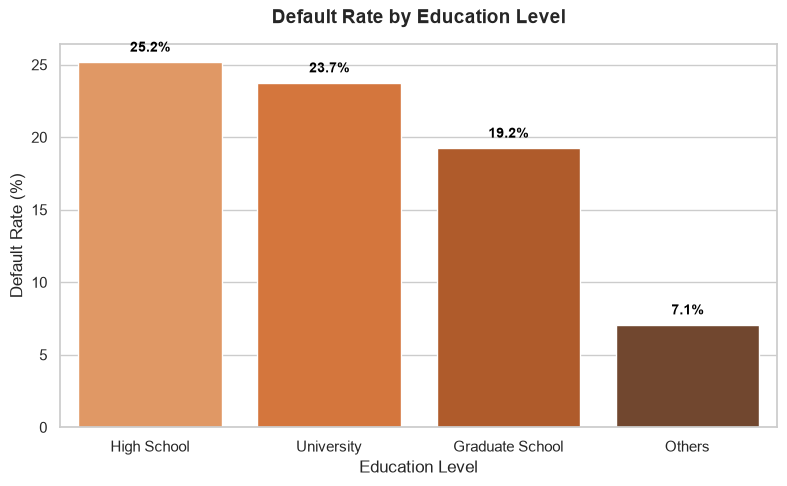

In [25]:
# Analysis & Plot 3: Default rate by Education Level
edu_default = df_clean.groupby('education')['default_next_month'].mean().reset_index()
edu_default['default_rate'] = edu_default['default_next_month'] * 100
edu_default = edu_default.sort_values(by='default_rate', ascending=False)

print(edu_default)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=edu_default, x='education', y='default_rate', palette='Oranges_d', ax=ax)
ax.set_title('Default Rate by Education Level', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Education Level', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='center', fontsize=10, weight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()


  marriage  default_next_month  default_rate
1   Others            0.236074     23.607427
0  Married            0.234626     23.462582
2   Single            0.209470     20.947005


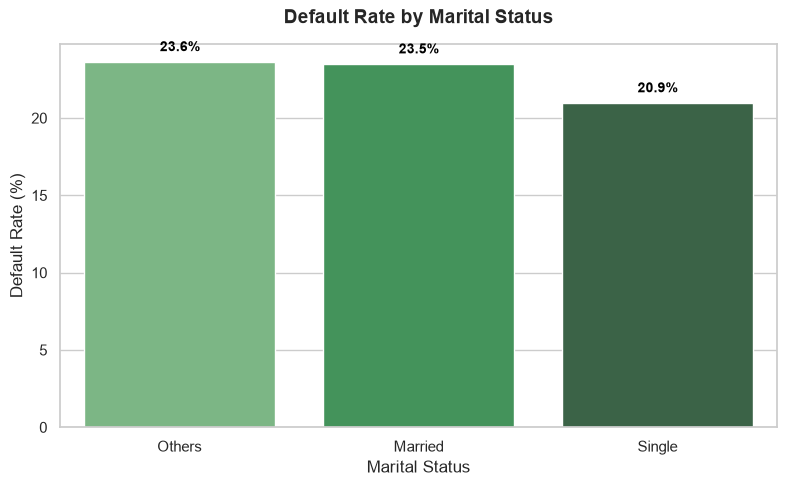

In [26]:
# Analysis & Plot 4: Default rate by Marital Status
marriage_default = df_clean.groupby('marriage')['default_next_month'].mean().reset_index()
marriage_default['default_rate'] = marriage_default['default_next_month'] * 100
marriage_default = marriage_default.sort_values(by='default_rate', ascending=False)

print(marriage_default)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=marriage_default, x='marriage', y='default_rate', palette='Greens_d', ax=ax)
ax.set_title('Default Rate by Marital Status', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Marital Status', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='center', fontsize=10, weight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()


          limit_tier  default_next_month  default_rate
0         Low (<50k)            0.317868     31.786785
1  Medium (50k-150k)            0.237319     23.731926
2   High (150k-300k)            0.168569     16.856921
3    Premium (300k+)            0.132162     13.216246


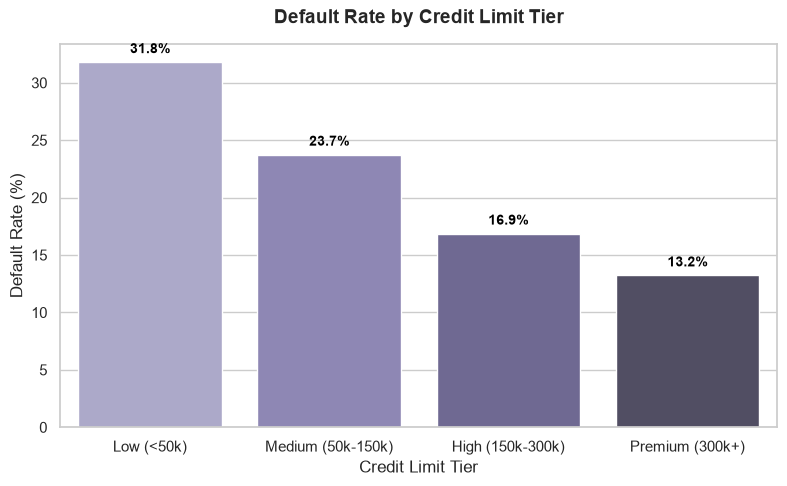

In [27]:
# Analysis & Plot 5: Default rate by Credit Limit Tiers
# Group limits into logical tiers: Low, Medium, High, Premium
limit_bins = [0, 50000, 150000, 300000, 10000000]
limit_labels = ['Low (<50k)', 'Medium (50k-150k)', 'High (150k-300k)', 'Premium (300k+)']
df_clean['limit_tier'] = pd.cut(df_clean['limit_balance'], bins=limit_bins, labels=limit_labels)

limit_default = df_clean.groupby('limit_tier')['default_next_month'].mean().reset_index()
limit_default['default_rate'] = limit_default['default_next_month'] * 100

print(limit_default)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=limit_default, x='limit_tier', y='default_rate', palette='Purples_d', ax=ax)
ax.set_title('Default Rate by Credit Limit Tier', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Credit Limit Tier', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='center', fontsize=10, weight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()


           pay_group_1  default_next_month  default_rate  sort_val
8  On Time / Paid Full            0.138375     13.837455       0.0
0     1 Month(s) Delay            0.340333     34.033270       1.0
1     2 Month(s) Delay            0.691298     69.129782       2.0
2     3 Month(s) Delay            0.757764     75.776398       3.0
3     4 Month(s) Delay            0.684211     68.421053       4.0
4     5 Month(s) Delay            0.500000     50.000000       5.0
5     6 Month(s) Delay            0.545455     54.545455       6.0
6     7 Month(s) Delay            0.777778     77.777778       7.0
7     8 Month(s) Delay            0.578947     57.894737       8.0


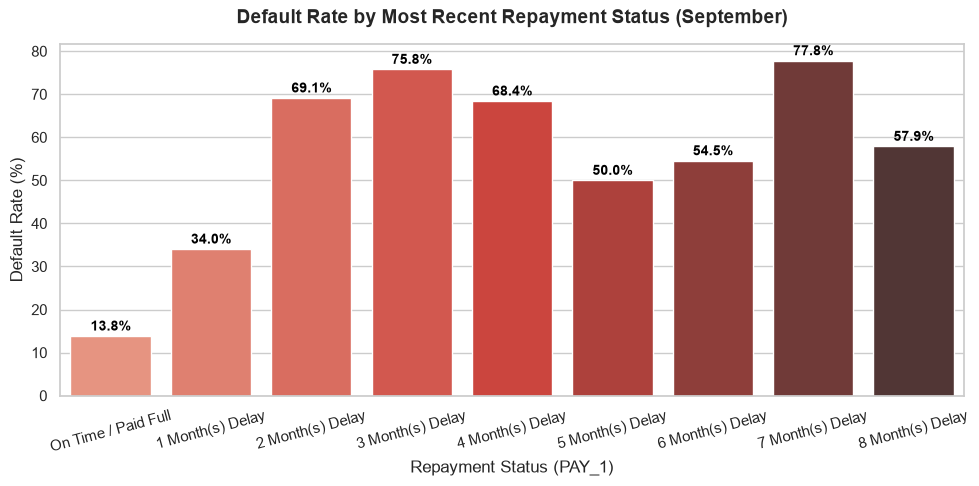

In [28]:
# Analysis & Plot 6: Delinquency status vs. Default probability
# Group repayment status on pay_status_1 (most recent month: September)
df_clean['pay_group_1'] = np.where(df_clean['pay_status_1'] <= 0, 'On Time / Paid Full', 
                                   df_clean['pay_status_1'].astype(str) + ' Month(s) Delay')

pay_default = df_clean.groupby('pay_group_1')['default_next_month'].mean().reset_index()
pay_default['default_rate'] = pay_default['default_next_month'] * 100

# Sort logically: On Time, then 1 month, 2 months, etc.
pay_default['sort_val'] = np.where(pay_default['pay_group_1'] == 'On Time / Paid Full', 0, 
                                   pay_default['pay_group_1'].str.extract('(\d+)').astype(float)[0])
pay_default = pay_default.sort_values(by='sort_val')

print(pay_default)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=pay_default, x='pay_group_1', y='default_rate', palette='Reds_d', ax=ax)
ax.set_title('Default Rate by Most Recent Repayment Status (September)', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Repayment Status (PAY_1)', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
plt.xticks(rotation=15)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='center', fontsize=10, weight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()


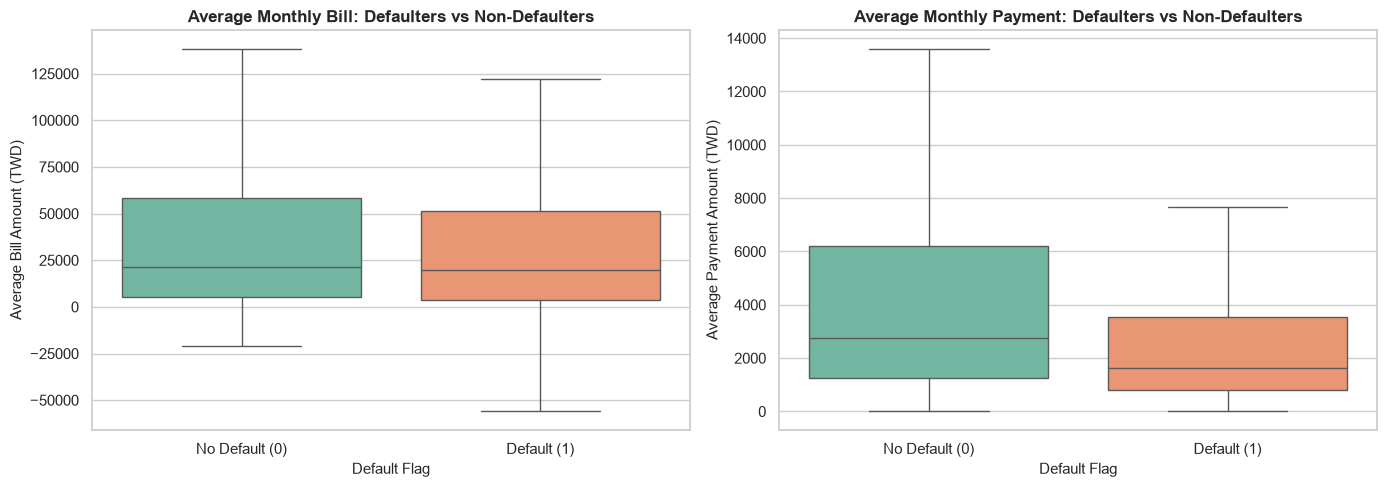

In [29]:
# Analysis & Plot 7: Bill amount vs. Payment amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average Bill Boxplot
sns.boxplot(data=df_clean, x='default_next_month', y='average_bill', palette='Set2', showfliers=False, ax=axes[0])
axes[0].set_title('Average Monthly Bill: Defaulters vs Non-Defaulters', fontsize=12, weight='bold')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'])
axes[0].set_xlabel('Default Flag', fontsize=11)
axes[0].set_ylabel('Average Bill Amount (TWD)', fontsize=11)

# Average Payment Boxplot
sns.boxplot(data=df_clean, x='default_next_month', y='average_payment', palette='Set2', showfliers=False, ax=axes[1])
axes[1].set_title('Average Monthly Payment: Defaulters vs Non-Defaulters', fontsize=12, weight='bold')
axes[1].set_xticklabels(['No Default (0)', 'Default (1)'])
axes[1].set_xlabel('Default Flag', fontsize=11)
axes[1].set_ylabel('Average Payment Amount (TWD)', fontsize=11)

plt.tight_layout()
plt.show()


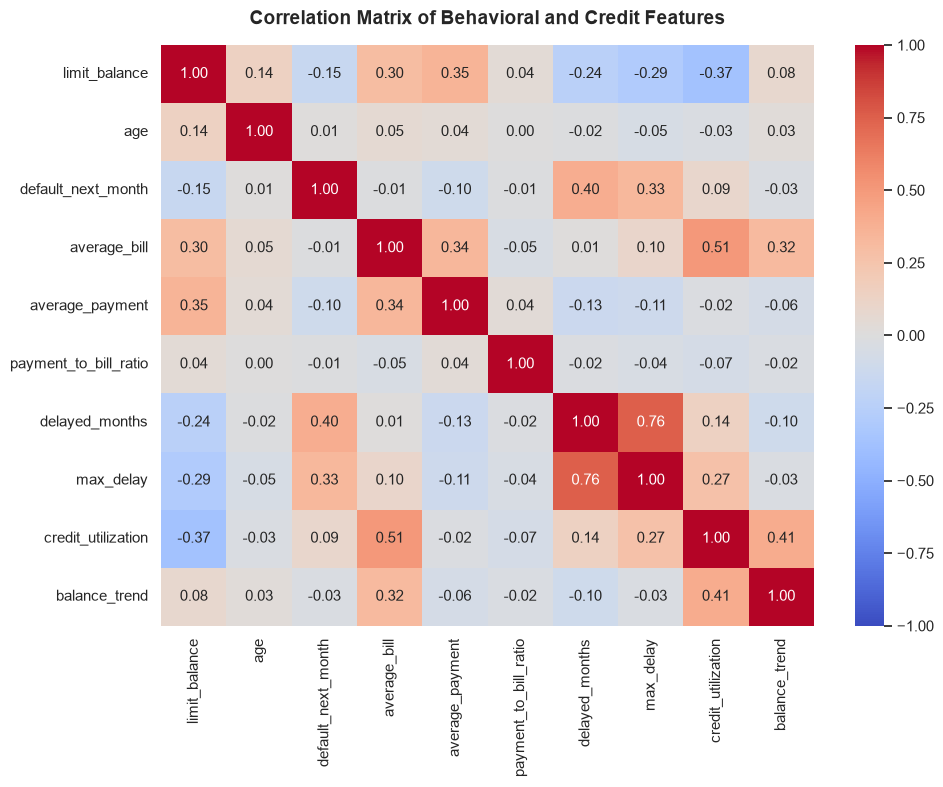

In [30]:
# Analysis & Plot 8: Correlation Heatmap
corr_cols = [
    'limit_balance', 'age', 'default_next_month', 
    'average_bill', 'average_payment', 'payment_to_bill_ratio', 
    'delayed_months', 'max_delay', 'credit_utilization', 'balance_trend'
]
corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix of Behavioral and Credit Features', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()


## Phase 3: Advanced Analytics: Credit-Risk Segmentation
We build an interpretable risk-scoring framework analogous to an RFM model based on:
1. **Delinquency Score** (Repayment delay history)
2. **Repayment Capacity Score** (Payment-to-bill ratio)
3. **Exposure Score** (Total outstanding balance relative to credit limit)

We combine these scores using a user-defined function and assign customers to the target segments: `Healthy`, `Watchlist`, `At-Risk`, and `Critical`.

In [31]:
# 1. Define scoring functions for Delinquency, Capacity, and Exposure
def get_delinquency_score(row):
    # Delinquency score (higher delay = higher risk)
    delay = row['delayed_months']
    if delay == 0:
        return 1
    elif delay == 1:
        return 2
    elif delay == 2:
        return 3
    elif delay <= 4:
        return 4
    else:
        return 5

def get_capacity_score(row):
    # Repayment Capacity score (lower payment-to-bill ratio = higher risk)
    ratio = row['payment_to_bill_ratio']
    if ratio >= 0.8:
        return 1
    elif ratio >= 0.4:
        return 2
    elif ratio >= 0.2:
        return 3
    elif ratio >= 0.05:
        return 4
    else:
        return 5

def get_exposure_score(row):
    # Exposure score (higher utilization = higher risk)
    util = row['credit_utilization']
    if util <= 0.1:
        return 1
    elif util <= 0.3:
        return 2
    elif util <= 0.6:
        return 3
    elif util <= 0.8:
        return 4
    else:
        return 5
print("Scoring functions defined successfully.")


Scoring functions defined successfully.


In [32]:
# 2. Calculate dimension scores (1-5) using pd.qcut or custom binning rules
df_clean['delinquency_score'] = df_clean.apply(get_delinquency_score, axis=1)
df_clean['capacity_score'] = df_clean.apply(get_capacity_score, axis=1)
df_clean['exposure_score'] = df_clean.apply(get_exposure_score, axis=1)

# Calculate combined score (ranges from 3 to 15)
df_clean['total_risk_score'] = df_clean['delinquency_score'] + df_clean['capacity_score'] + df_clean['exposure_score']

print("Dimension scores computed. Summary stats:")
print(df_clean[['delinquency_score', 'capacity_score', 'exposure_score', 'total_risk_score']].describe())


Dimension scores computed. Summary stats:
       delinquency_score  capacity_score  exposure_score  total_risk_score
count       29965.000000    29965.000000    29965.000000      29965.000000
mean            1.703154        3.475688        2.763591          7.942433
std             1.188689        1.528831        1.649679          3.366411
min             1.000000        1.000000        1.000000          3.000000
25%             1.000000        2.000000        1.000000          5.000000
50%             1.000000        4.000000        3.000000          8.000000
75%             2.000000        5.000000        5.000000         11.000000
max             5.000000        5.000000        5.000000         15.000000


In [33]:
# 3. Combine scores and map to business-friendly segments
def map_to_segment(total_score):
    if total_score <= 5:
        return 'Healthy'
    elif total_score <= 8:
        return 'Watchlist'
    elif total_score <= 11:
        return 'At-Risk'
    else:
        return 'Critical'

df_clean['risk_segment'] = df_clean['total_risk_score'].apply(map_to_segment)
print("Decoded segments sizes:")
print(df_clean['risk_segment'].value_counts())


Decoded segments sizes:
risk_segment
At-Risk      10402
Healthy       9085
Watchlist     6594
Critical      3884
Name: count, dtype: int64


--- Risk Segment Validation stats ---
  risk_segment  count  defaults  default_rate  risk_order
2      Healthy   9085      1262     13.891029           1
3    Watchlist   6594      1081     16.393691           2
0      At-Risk  10402      2153     20.697943           3
1     Critical   3884      2134     54.943357           4


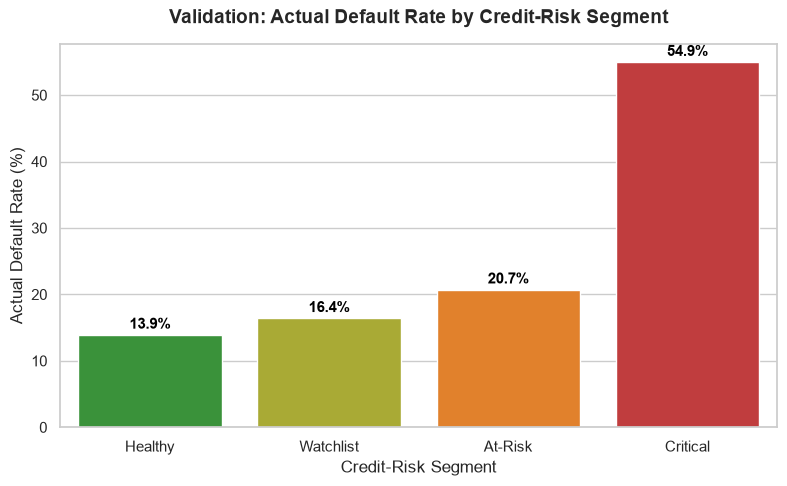

In [34]:
# 4. Validate segments by computing actual default rates per segment
segment_stats = df_clean.groupby('risk_segment').agg(
    count=('default_next_month', 'count'),
    defaults=('default_next_month', 'sum'),
    default_rate=('default_next_month', 'mean')
).reset_index()
segment_stats['default_rate'] = segment_stats['default_rate'] * 100

# Sort in risk order
segment_stats['risk_order'] = segment_stats['risk_segment'].map({'Healthy': 1, 'Watchlist': 2, 'At-Risk': 3, 'Critical': 4})
segment_stats = segment_stats.sort_values('risk_order')

print("--- Risk Segment Validation stats ---")
print(segment_stats)

# Visual validation of default rates
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ca02c', '#bcbd22', '#ff7f0e', '#d62728']
sns.barplot(data=segment_stats, x='risk_segment', y='default_rate', palette=colors, ax=ax)
ax.set_title('Validation: Actual Default Rate by Credit-Risk Segment', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Credit-Risk Segment', fontsize=12)
ax.set_ylabel('Actual Default Rate (%)', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='center', fontsize=11, weight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')
plt.tight_layout()
plt.show()


## Phase 4: Strategic Recommendations & Utilisation Analysis
We analyze customer credit utilization and financial exposure to provide tailored credit risk policies for each segment.

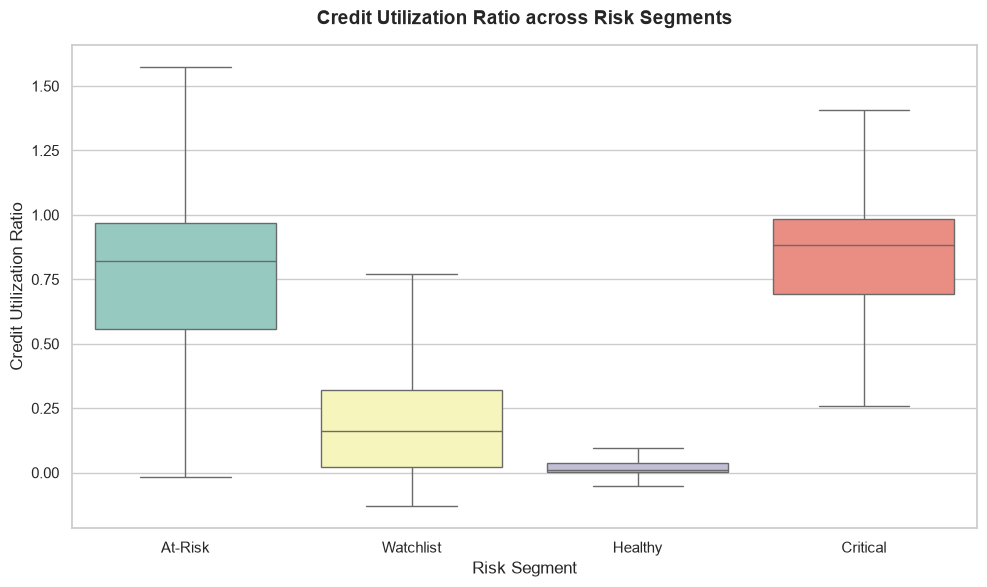


--- Average Credit Utilization by Segment ---
  risk_segment  credit_utilization
0      At-Risk            0.752665
1     Critical            0.830502
2      Healthy            0.031804
3    Watchlist            0.207645


In [35]:
# Boxplot / Histogram of credit utilization across different segments
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_clean, x='risk_segment', y='credit_utilization', palette='Set3', showfliers=False, ax=ax)
ax.set_title('Credit Utilization Ratio across Risk Segments', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Risk Segment', fontsize=12)
ax.set_ylabel('Credit Utilization Ratio', fontsize=12)
plt.tight_layout()
plt.show()

# Print average credit utilization
util_stats = df_clean.groupby('risk_segment')['credit_utilization'].mean().reset_index()
print("\n--- Average Credit Utilization by Segment ---")
print(util_stats)


## Phase 5: Data Enrichment via API Integration
Here we pull real-time external data (exchange rates, macroeconomic indicators) using the `requests` library to enrich our database and report financial metrics in USD/EUR.

In [36]:
# Define API endpoint (e.g. ExchangeRate-API or Open Exchange Rates)
# Fetching currency rates using USD as base
url = "https://open.er-api.com/v6/latest/USD"
print(f"Fetching exchange rates from: {url}")

try:
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    data = response.json()
    
    # Output sample response metadata
    print("API Response Status:", data.get("result"))
    print("Base Currency:", data.get("base_code"))
    print("TWD rate found:", data.get("rates", {}).get("TWD"))
    
    usd_to_twd = data.get("rates", {}).get("TWD")
    if usd_to_twd:
        twd_to_usd_rate = 1.0 / usd_to_twd
        print(f"Success: 1 TWD = {twd_to_usd_rate:.6f} USD")
    else:
        twd_to_usd_rate = 1.0 / 32.5
        print("TWD rate not in API response. Using fallback: 1 TWD = 0.0307 USD")
except Exception as e:
    print(f"API request failed: {e}")
    twd_to_usd_rate = 1.0 / 32.5
    print("Using fallback exchange rate: 1 TWD = 0.0307 USD")


Fetching exchange rates from: https://open.er-api.com/v6/latest/USD
API Response Status: success
Base Currency: USD
TWD rate found: 32.099057
Success: 1 TWD = 0.031154 USD


In [37]:
# Apply enrichment to the main DataFrame (e.g., LIMIT_BAL_USD)
# Convert LIMIT_BAL and average_bill to USD
df_clean['limit_balance_usd'] = df_clean['limit_balance'] * twd_to_usd_rate
df_clean['average_bill_usd'] = df_clean['average_bill'] * twd_to_usd_rate

print("Dataset enriched with USD converted columns. Preview:")
print(df_clean[['limit_balance', 'limit_balance_usd', 'average_bill', 'average_bill_usd']].head())

# Save the final processed dataset
output_path = "../data/processed/cleaned_credit_data.csv"
df_clean.to_csv(output_path, index=False)
print(f"\nFinal enriched and cleaned dataset saved to: {output_path}")


Dataset enriched with USD converted columns. Preview:
   limit_balance  limit_balance_usd  average_bill  average_bill_usd
0          20000         623.071263   1284.000000         40.001175
1         120000        3738.427581   2846.166667         88.668233
2          90000        2803.820685  16942.166667        527.808860
3          50000        1557.678159  38555.666667       1201.146397
4          50000        1557.678159  18223.166667        567.716574

Final enriched and cleaned dataset saved to: ../data/processed/cleaned_credit_data.csv
